In [23]:
#importing the libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve

In [24]:
data=pd.read_csv(r'Phase_2_Preprocessed_Dataset.csv')
data.head()

,Patient_ID,Name,Age,Gender,BMI,Blood_Pressure,Glucose,Cholesterol,Smoking,Physical_Activity,Family_History,Disease
0,1,Anika Jain,60,Male,33.0,136,70,171,0,1,1,0
1,2,Vivaan Reddy,61,Female,17.0,101,189,316,1,0,1,1
2,3,Reyansh Kumar,47,Female,26.9,106,151,300,1,0,0,1
3,4,Vihaan Patel,78,Female,29.4,149,174,260,0,1,1,1
4,5,Krishna Reddy,42,Female,26.6,123,103,273,0,0,0,1


In [25]:
# Converting the categorical values to numerical values

data['Gender']=data['Gender'].map({'Male':1,'Female':0})
data=data.drop(['Patient_ID','Name'],axis=1)
X=data.drop('Disease',axis=1)
y=data['Disease']
X
y

0       0
1       1
2       1
3       1
4       1
       ..
9995    1
9996    1
9997    1
9998    1
9999    1
Name: Disease, Length: 10000, dtype: int64

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [27]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train
X_test

array([[-1.30723981, -0.99345002,  0.55468352, ...,  1.03046381,
        -0.98328257,  1.02429504],
       [-0.5810398 ,  1.00659316, -0.71829422, ...,  1.03046381,
         1.01700165,  1.02429504],
       [-0.63690134,  1.00659316,  1.3502946 , ..., -0.97043679,
        -0.98328257, -0.97628121],
       ...,
       [-0.74862442, -0.99345002, -0.73275987, ..., -0.97043679,
        -0.98328257, -0.97628121],
       [-0.69276288, -0.99345002, -0.3277215 , ...,  1.03046381,
        -0.98328257, -0.97628121],
       [ 0.48032943, -0.99345002, -0.70382856, ..., -0.97043679,
        -0.98328257,  1.02429504]], shape=(3000, 9))

In [28]:
def evaluate(y_test,y_pred):
 print('Accuracy:',accuracy_score(y_test,y_pred))
 print('Precision:',precision_score(y_test,y_pred))
 print('Recall:',recall_score(y_test,y_pred))
 print('F1:',f1_score(y_test,y_pred))
 print('Confusion Matrix:\n',confusion_matrix(y_test,y_pred))

In [29]:
#implying logistic regression

lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
print('LR')
evaluate(y_test,y_pred_lr)

LR
Accuracy: 0.8756666666666667
Precision: 0.8955854126679462
Recall: 0.9585045193097781
F1: 0.925977376463584
Confusion Matrix:
 [[ 294  272]
 [ 101 2333]]


In [30]:
#implying KNN

knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)
print('KNN')
evaluate(y_test,y_pred_knn)

KNN
Accuracy: 0.9333333333333333
Precision: 0.9471577261809447
Recall: 0.9720624486442071
F1: 0.959448499594485
Confusion Matrix:
 [[ 434  132]
 [  68 2366]]


In [31]:
#implying svm

svm=SVC(probability=True)
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
print('SVM')
evaluate(y_test,y_pred_svm)

SVM
Accuracy: 0.9536666666666667
Precision: 0.9602888086642599
Recall: 0.9835661462612982
F1: 0.9717881063527501
Confusion Matrix:
 [[ 467   99]
 [  40 2394]]


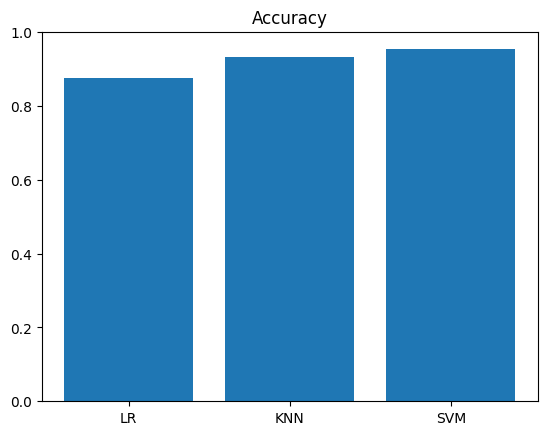

In [32]:
#visual representation of accuracy 

acc=[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_knn),accuracy_score(y_test,y_pred_svm)]
plt.bar(['LR','KNN','SVM'],acc)
plt.title('Accuracy')
plt.show()

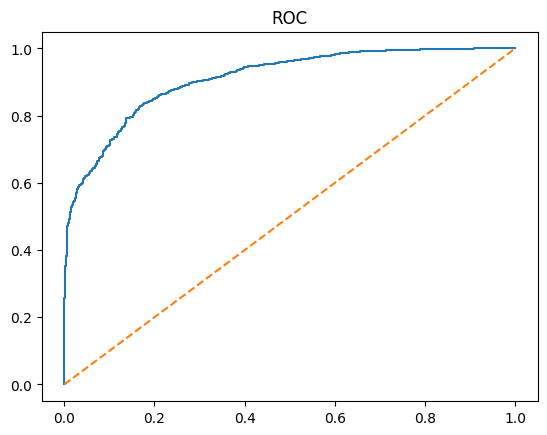

In [33]:
#roc curve representation

y_prob=lr.predict_proba(X_test)[:,1]
fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC')
plt.show()

Confusion Matrix:
 [[ 467   99]
 [  40 2394]]


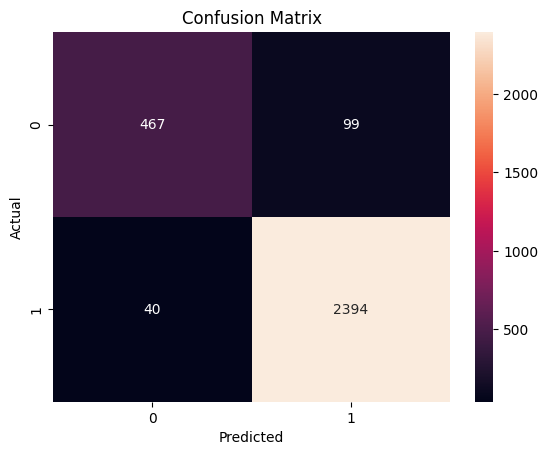

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for SVM (you can change model if needed)
cm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [35]:
#model evaluation

In [36]:
results = {
    'Model': ['LR', 'KNN', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm)
    ]
}

import pandas as pd
df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,F1 Score
0,LR,0.875667,0.925977
1,KNN,0.933333,0.959448
2,SVM,0.953667,0.971788


In [37]:
best_model = svm  

In [38]:
def predict_disease(input_data):
    input_data = scaler.transform([input_data])
    result = best_model.predict(input_data)
    return result

In [39]:
#person not having any disease(healthy person)

predict_disease([60,1,33,136,70,171,0,1,1])

C:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [40]:
#person having disease(not healthy)

predict_disease([61,0,17,101,189,316,1,0,1])

C:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])

In [41]:
data[data['Disease'] == 0].head()

,Age,Gender,BMI,Blood_Pressure,Glucose,Cholesterol,Smoking,Physical_Activity,Family_History,Disease
0,60,1,33.0,136,70,171,0,1,1,0
11,47,1,26.7,113,125,161,1,0,1,0
15,34,0,37.1,88,90,158,1,0,1,0
22,42,1,27.8,135,157,162,1,1,1,0
24,43,1,23.0,84,155,150,1,0,0,0


In [42]:
data[data['Disease'] == 1].head()

,Age,Gender,BMI,Blood_Pressure,Glucose,Cholesterol,Smoking,Physical_Activity,Family_History,Disease
1,61,0,17.0,101,189,316,1,0,1,1
2,47,0,26.9,106,151,300,1,0,0,1
3,78,0,29.4,149,174,260,0,1,1,1
4,42,0,26.6,123,103,273,0,0,0,1
5,38,1,37.4,158,98,269,1,0,1,1
